# Noise in LJ trajectories in equilibrium


## Overview

This notebook compares equilibrium position and displacement statistics with global translation retained and removed.

1. **Particle position clouds:** per-particle Gaussianity and covariance.
2. **Radius of gyration:** spatial size of each particle's position cloud.
3. **Global displacement cloud:** one distribution pooled over particles.
4. **Local displacement clouds:** one distribution per particle.


## Setup

Set `RUN_MODE` to `"quick"`, `"heavy"`, or `"full"`. Full mode loads all 108,000 atoms and is RAM-intensive.


In [66]:
# Choose "quick", "heavy", or "full".
RUN_MODE = "heavy"
SEED = 7
EXPERIMENT_5_SEED = 11
EXPERIMENT_5A_STEP_STD = 0.073
FRAME_STRIDE = 1

if RUN_MODE == "quick":
    PARTICLE_CLOUD_N_PARTICLES = 40
    PARTICLE_CLOUD_N_FRAMES = 60
    RG_N_PARTICLES = 80
    RG_N_FRAMES = 60
    DISPLACEMENT_N_PARTICLES = 40
    DISPLACEMENT_FRAMES = {"fcc": 60, "hcp": 60, "liquid": 60}
elif RUN_MODE == "heavy":
    PARTICLE_CLOUD_N_PARTICLES = 2000
    PARTICLE_CLOUD_N_FRAMES = 601
    RG_N_PARTICLES = 2000
    RG_N_FRAMES = 601
    DISPLACEMENT_N_PARTICLES = 2000
    DISPLACEMENT_FRAMES = {"fcc": 601, "hcp": 601, "liquid": 301}
elif RUN_MODE == "full":
    # None means every atom in the trajectory.
    PARTICLE_CLOUD_N_PARTICLES = None
    PARTICLE_CLOUD_N_FRAMES = 601
    RG_N_PARTICLES = None
    RG_N_FRAMES = 601
    DISPLACEMENT_N_PARTICLES = None
    DISPLACEMENT_FRAMES = {"fcc": 601, "hcp": 601, "liquid": 301}
else:
    raise ValueError('RUN_MODE must be "quick", "heavy", or "full".')

print("run mode:", RUN_MODE)


run mode: heavy


In [67]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import chi2, kstest, norm
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False




def find_data_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples",
        Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples").resolve(),
    ]
    for candidate in candidates:
        if (candidate / "fcc/traj.lammpstrj").exists():
            return candidate
    raise FileNotFoundError("Could not locate statistically_independent_samples data directory.")


DATA_DIR = find_data_dir()
TRAJECTORIES = {
    "fcc": DATA_DIR / "fcc/traj.lammpstrj",
    "hcp": DATA_DIR / "hcp/traj.lammpstrj",
    "liquid": DATA_DIR / "liquid/trajectory1.lammpstrj",
}
MODES = {"fcc": "site", "hcp": "site", "liquid": "increments"}


def _coord_columns(atom_columns):
    if {"xs", "ys", "zs"}.issubset(atom_columns):
        return [atom_columns.index(c) for c in ("xs", "ys", "zs")], True
    if {"x", "y", "z"}.issubset(atom_columns):
        return [atom_columns.index(c) for c in ("x", "y", "z")], False
    raise ValueError(f"No x/y/z or xs/ys/zs columns found in {atom_columns}.")


def read_sampled_lammpstrj(
    path,
    n_particles,
    max_frames,
    frame_stride=FRAME_STRIDE,
    start_frame=0,
    seed=SEED,
    atom_ids=None,
):
    """Stream a small fixed-ID sample from a LAMMPS dump."""
    rng = np.random.default_rng(seed)
    selected_ids = None if atom_ids is None else np.asarray(atom_ids, dtype=np.int64)
    positions, boxes, timesteps = [], [], []

    with Path(path).open() as handle:
        frame_number = -1
        while len(positions) < max_frames:
            line = handle.readline()
            if not line:
                break
            if not line.startswith("ITEM: TIMESTEP"):
                raise ValueError(f"Expected ITEM: TIMESTEP, got {line.strip()!r} in {path}")

            frame_number += 1
            timestep = int(handle.readline())

            if not handle.readline().startswith("ITEM: NUMBER OF ATOMS"):
                raise ValueError("Malformed dump: missing atom-count header.")
            natoms = int(handle.readline())

            if not handle.readline().startswith("ITEM: BOX BOUNDS"):
                raise ValueError("Malformed dump: missing box header.")
            bounds = np.array([handle.readline().split()[:2] for _ in range(3)], dtype=float)
            lo = bounds[:, 0]
            box = bounds[:, 1] - bounds[:, 0]

            atom_columns = handle.readline().split()[2:]
            id_col = atom_columns.index("id")
            xyz_cols, scaled = _coord_columns(atom_columns)

            if selected_ids is None:
                if n_particles is None or int(n_particles) >= natoms:
                    selected_ids = np.arange(1, natoms + 1, dtype=np.int64)
                else:
                    selected_ids = np.sort(
                        rng.choice(
                            np.arange(1, natoms + 1),
                            size=int(n_particles),
                            replace=False,
                        )
                    )

            use_frame = frame_number >= start_frame and (frame_number - start_frame) % frame_stride == 0
            if not use_frame:
                for _ in range(natoms):
                    handle.readline()
                continue

            id_to_row = {int(atom_id): row for row, atom_id in enumerate(selected_ids)}
            frame = np.empty((len(selected_ids), 3), dtype=np.float64)
            found = 0
            for _ in range(natoms):
                fields = handle.readline().split()
                row = id_to_row.get(int(fields[id_col]))
                if row is None:
                    continue
                xyz = np.array([float(fields[col]) for col in xyz_cols], dtype=np.float64)
                frame[row] = lo + xyz * box if scaled else xyz
                found += 1

            if found != len(selected_ids):
                raise ValueError(f"Only found {found}/{len(selected_ids)} selected atoms in {path}.")
            positions.append(frame)
            boxes.append(box)
            timesteps.append(timestep)

    if len(positions) < 2:
        raise ValueError(f"Need at least two sampled frames from {path}.")
    return np.stack(positions), np.stack(boxes), np.asarray(timesteps), selected_ids


def minimum_image(delta, box):
    box = np.asarray(box, dtype=np.float64)
    if box.ndim == 1:
        return delta - box * np.round(delta / box)
    return delta - box[:, None, :] * np.round(delta / box[:, None, :])


def displacements_from_positions(positions, boxes, mode):
    if mode == "increments":
        disp = minimum_image(np.diff(positions, axis=0), boxes[1:])
    elif mode == "site":
        relative = minimum_image(positions - positions[0][None, :, :], boxes)
        local = positions[0][None, :, :] + relative
        disp = local - local.mean(axis=0, keepdims=True)
    else:
        raise ValueError("mode must be 'site' or 'increments'.")

    # Remove any global translation in each sampled frame.
    return disp - disp.mean(axis=1, keepdims=True)


## Experiment 1: Particle position clouds

Tests whether each particle's positions around its temporal mean are approximately Gaussian.


n_frames  n_particles  median_anisotropy  \
label translation                                                      
fcc   translation retained       601         2000          10.106574   
      translation removed        601         2000           1.180529   
hcp   translation retained       601         2000          10.132768   
      translation removed        601         2000           1.190829   

                            median_ks_p  fraction_ks_p_below_0.05  \
label translation                                                   
fcc   translation retained     0.008362                    0.8605   
      translation removed      0.698961                    0.0045   
hcp   translation retained     0.007389                    0.8645   
      translation removed      0.687531                    0.0065   

                            median_max_abs_skew  \
label translation                                 
fcc   translation retained             0.475957   
      translation removed              0.132674   
hcp   translation retained             0.474758   
      translation removed              0.138059   

                            median_max_abs_excess_kurtosis  
label translation                                           
fcc   translation retained                        0.657017  
      translation removed                         0.268936  
hcp   translation retained                        0.659728  
      translation removed                         0.253346


FCC, translation retained: representative atom id 26682
mean position: [16.15084 14.3296  43.33101]
Mahalanobis KS p-value: 0.0674
anisotropy ratio: 9.461


,x,y,z
x,0.064951,0.038738,0.001817
y,0.038738,0.039123,0.003802
z,0.001817,0.003802,0.012985



FCC, translation removed: representative atom id 26682
mean position: [15.6676 14.1703 43.2906]
Mahalanobis KS p-value: 0.6992
anisotropy ratio: 1.195


,x,y,z
x,0.006056,-0.000062,0.000340
y,-0.000062,0.005733,0.000304
z,0.000340,0.000304,0.005598



HCP, translation retained: representative atom id 107061
mean position: [21.59967 44.04681 48.30854]
Mahalanobis KS p-value: 0.0021
anisotropy ratio: 9.256


,x,y,z
x,0.062740,0.038799,0.000344
y,0.038799,0.040301,0.002542
z,0.000344,0.002542,0.012754



HCP, translation removed: representative atom id 107061
mean position: [21.11684 43.88611 48.26539]
Mahalanobis KS p-value: 0.6877
anisotropy ratio: 1.218


,x,y,z
x,0.005734,0.000072,0.000481
y,0.000072,0.006287,0.000091
z,0.000481,0.000091,0.005677


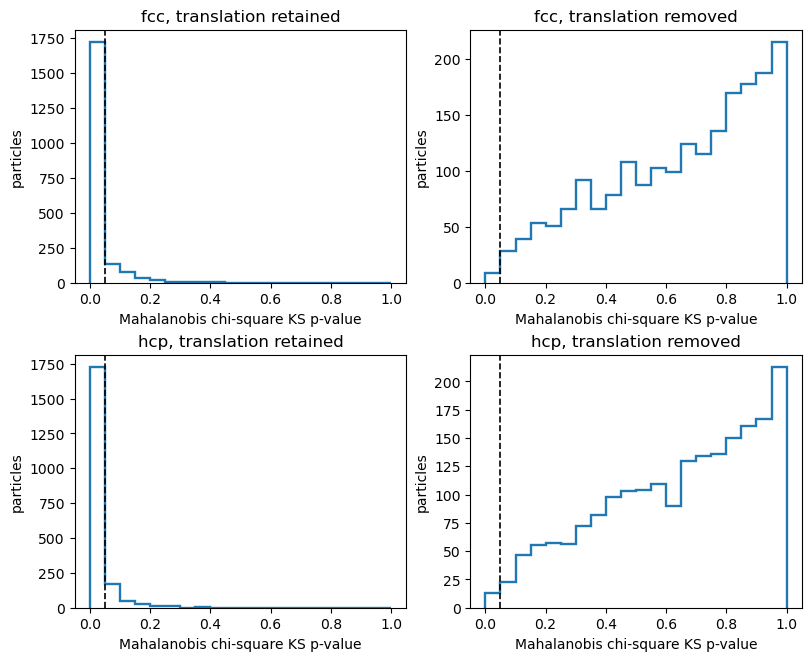

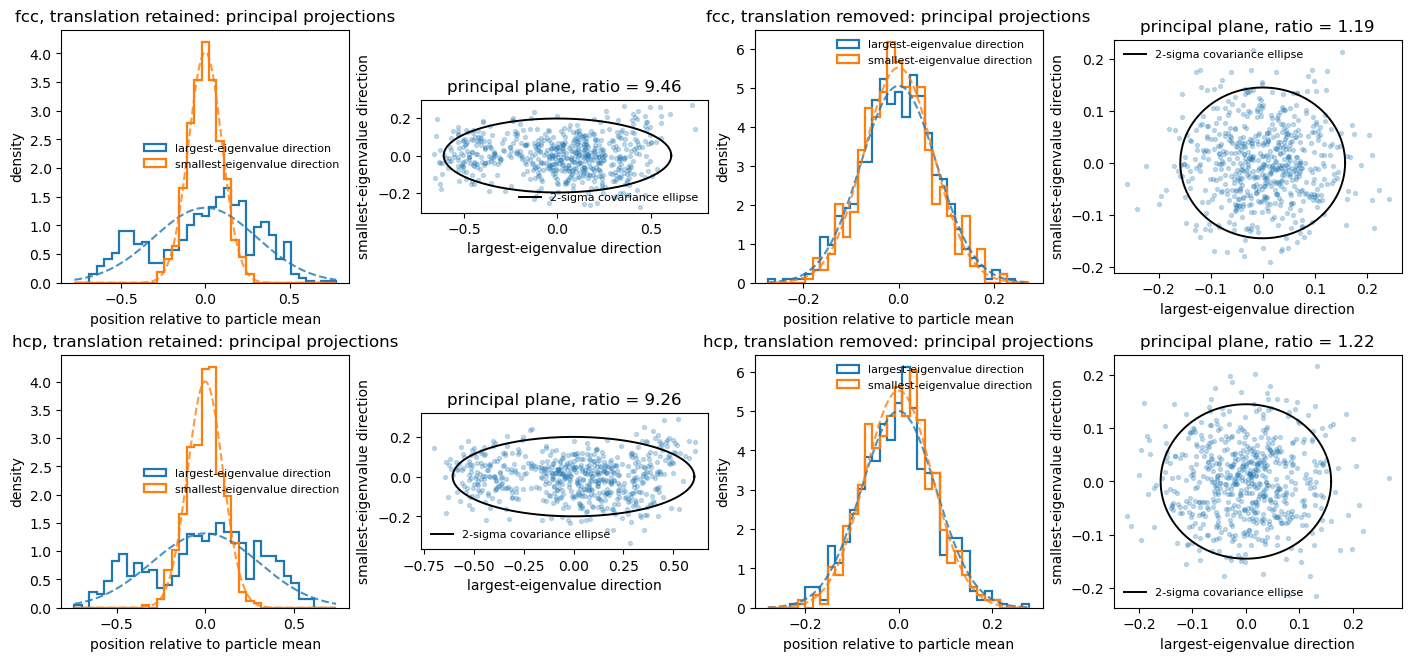

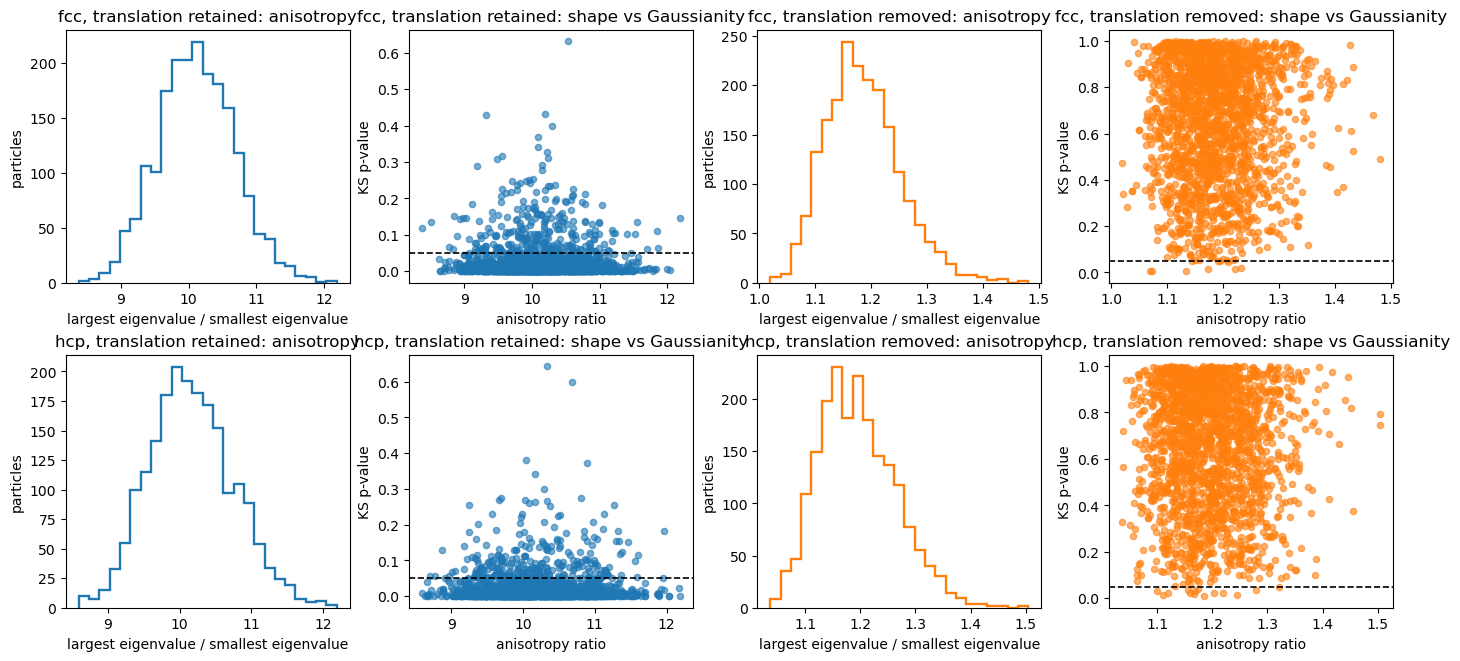

In [68]:
# Experiment 1: Is each particle's position cloud approximately Gaussian?



def unwrap_positions(positions, boxes):
    """Unwrap all particle positions through an orthorhombic periodic box."""
    positions = np.asarray(positions, dtype=np.float64)
    boxes = np.asarray(boxes, dtype=np.float64)
    if positions.ndim != 3 or positions.shape[2] != 3:
        raise ValueError("positions must have shape (n_frames, n_particles, 3).")
    if boxes.shape not in {(3,), (len(positions), 3)}:
        raise ValueError("boxes must have shape (3,) or (n_frames, 3).")

    step_boxes = boxes if boxes.ndim == 1 else boxes[1:]
    steps = minimum_image(np.diff(positions, axis=0), step_boxes)
    return np.concatenate([
        positions[:1],
        positions[:1] + np.cumsum(steps, axis=0),
    ], axis=0)


def remove_shared_translation(unwrapped):
    """Remove the mean displacement shared by the sampled particles per frame."""
    translation = (unwrapped - unwrapped[:1]).mean(axis=1, keepdims=True)
    return unwrapped - translation


def calculate_gaussian_distribution(unwrapped):
    """Calculate one temporal mean and covariance matrix per particle."""
    centers = unwrapped.mean(axis=0)
    centered = unwrapped - centers[None, :, :]
    covariances = np.einsum("tni,tnj->nij", centered, centered) / (len(unwrapped) - 1)
    return centers, centered, covariances


def calculate_gaussianity_metrics(centered, covariances):
    """Calculate simple Gaussian diagnostics for every particle cloud."""
    inverse_covariances = np.linalg.pinv(covariances)
    mahalanobis_d2 = np.einsum(
        "tni,nij,tnj->tn", centered, inverse_covariances, centered
    )
    mahalanobis_ks_p = np.array([
        kstest(mahalanobis_d2[:, particle], chi2(df=3).cdf).pvalue
        for particle in range(centered.shape[1])
    ])

    standard_deviation = centered.std(axis=0, ddof=1)
    standard_deviation = np.maximum(standard_deviation, np.finfo(float).eps)
    standardized = centered / standard_deviation[None, :, :]
    marginal_skew = np.mean(standardized**3, axis=0)
    marginal_excess_kurtosis = np.mean(standardized**4, axis=0) - 3.0

    return {
        "mahalanobis_d2": mahalanobis_d2,
        "mahalanobis_ks_p": mahalanobis_ks_p,
        "marginal_skew_xyz": marginal_skew,
        "marginal_excess_kurtosis_xyz": marginal_excess_kurtosis,
    }


def particle_cloud_report(label, positions, boxes, remove_global_translation=True):
    """Analyze the position point cloud of every sampled particle."""
    unwrapped = unwrap_positions(positions, boxes)
    if remove_global_translation:
        unwrapped = remove_shared_translation(unwrapped)

    centers, centered, covariances = calculate_gaussian_distribution(unwrapped)
    metrics = calculate_gaussianity_metrics(centered, covariances)

    eigenvalues, eigenvectors = np.linalg.eigh(covariances)
    eigenvalues = eigenvalues[:, ::-1]
    eigenvectors = eigenvectors[:, :, ::-1]
    anisotropy = eigenvalues[:, 0] / np.maximum(
        eigenvalues[:, -1], np.finfo(float).eps
    )

    return {
        "label": label,
        "remove_global_translation": remove_global_translation,
        "n_frames": len(positions),
        "n_particles": positions.shape[1],
        "centers": centers,
        "centered_positions": centered,
        "covariances": covariances,
        "covariance_eigenvalues": eigenvalues,
        "covariance_eigenvectors": eigenvectors,
        "anisotropy_ratio": anisotropy,
        **metrics,
    }


def trajectory_particle_cloud_reports(
    label,
    path,
    n_particles=PARTICLE_CLOUD_N_PARTICLES,
    n_frames=PARTICLE_CLOUD_N_FRAMES,
    seed=SEED,
):
    """Read fixed particle IDs once, then analyze with and without translation."""
    positions, boxes, timesteps, atom_ids = read_sampled_lammpstrj(
        path,
        n_particles=n_particles,
        max_frames=n_frames,
        frame_stride=1,
        seed=seed,
    )
    if len(positions) != n_frames:
        raise ValueError(f"Requested {n_frames} frames, but {path} contains only {len(positions)}.")

    reports = {}
    for remove_translation in (False, True):
        name = "translation removed" if remove_translation else "translation retained"
        report = particle_cloud_report(label, positions, boxes, remove_translation)
        report["atom_ids"] = atom_ids
        report["timesteps"] = timesteps
        reports[name] = report
    return reports


# Position clouds require stable mean sites, so this experiment uses FCC/HCP only.
particle_cloud_reports = {
    label: trajectory_particle_cloud_reports(label, TRAJECTORIES[label])
    for label in ("fcc", "hcp")
}

particle_cloud_summary = []
for label, translation_reports in particle_cloud_reports.items():
    for translation_name, report in translation_reports.items():
        p_values = report["mahalanobis_ks_p"]
        skew = report["marginal_skew_xyz"]
        kurtosis = report["marginal_excess_kurtosis_xyz"]
        particle_cloud_summary.append({
            "label": label,
            "translation": translation_name,
            "n_frames": report["n_frames"],
            "n_particles": report["n_particles"],
            "median_anisotropy": np.median(report["anisotropy_ratio"]),
            "median_ks_p": np.median(p_values),
            "fraction_ks_p_below_0.05": np.mean(p_values < 0.05),
            "median_max_abs_skew": np.median(np.max(np.abs(skew), axis=1)),
            "median_max_abs_excess_kurtosis": np.median(
                np.max(np.abs(kurtosis), axis=1)
            ),
        })

particle_cloud_summary = pd.DataFrame(particle_cloud_summary).set_index(
    ["label", "translation"]
)
display(particle_cloud_summary)

# Select one atom per structure from the translation-removed result, then use
# that identical atom for both modes so the comparison is particle-for-particle.
representative_particles = {}
for label, translation_reports in particle_cloud_reports.items():
    reference = translation_reports["translation removed"]
    p_values = reference["mahalanobis_ks_p"]
    representative_particles[label] = int(np.argsort(p_values)[len(p_values) // 2])

for label, translation_reports in particle_cloud_reports.items():
    particle = representative_particles[label]
    atom_id = int(translation_reports["translation removed"]["atom_ids"][particle])
    for translation_name, report in translation_reports.items():
        print()
        print(f"{label.upper()}, {translation_name}: representative atom id {atom_id}")
        print("mean position:", np.array2string(report["centers"][particle], precision=5))
        print("Mahalanobis KS p-value:", f"{report['mahalanobis_ks_p'][particle]:.4f}")
        print("anisotropy ratio:", f"{report['anisotropy_ratio'][particle]:.3f}")
        display(pd.DataFrame(
            report["covariances"][particle], index=list("xyz"), columns=list("xyz")
        ))

# Compare Gaussian diagnostics without overlaying separated populations.
fig, axes = plt.subplots(2, 2, figsize=(8, 6.5), constrained_layout=True)
translation_order = ("translation retained", "translation removed")

for row, label in enumerate(("fcc", "hcp")):
    for column, translation_name in enumerate(translation_order):
        report = particle_cloud_reports[label][translation_name]
        ax = axes[row, column]
        ax.hist(
            report["mahalanobis_ks_p"], bins=20, range=(0, 1),
            histtype="step", lw=1.7,
        )
        ax.axvline(0.05, color="black", lw=1.2, linestyle="--")
        ax.set_title(f"{label}, {translation_name}")
        ax.set_xlabel("Mahalanobis chi-square KS p-value")
        ax.set_ylabel("particles")

plt.show()

# Show the same representative particle in its maximum/minimum covariance plane.
# Raw projections show directional width; Gaussian overlays show distribution shape.
translation_order = ("translation retained", "translation removed")
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), constrained_layout=True)

for row, label in enumerate(("fcc", "hcp")):
    particle = representative_particles[label]
    for mode, translation_name in enumerate(translation_order):
        report = particle_cloud_reports[label][translation_name]
        centered = report["centered_positions"][:, particle, :]
        eigenvalues = report["covariance_eigenvalues"][particle]
        eigenvectors = report["covariance_eigenvectors"][particle]

        largest = centered @ eigenvectors[:, 0]
        smallest = centered @ eigenvectors[:, -1]
        anisotropy = eigenvalues[0] / eigenvalues[-1]

        histogram_axis = axes[row, 2 * mode]
        scatter_axis = axes[row, 2 * mode + 1]

        projection_limit = 1.05 * np.max(np.abs(np.concatenate([largest, smallest])))
        bins = np.linspace(-projection_limit, projection_limit, 36)
        x = np.linspace(-projection_limit, projection_limit, 400)

        histogram_axis.hist(
            largest, bins=bins, density=True, histtype="step", lw=1.6,
            label="largest-eigenvalue direction",
        )
        histogram_axis.hist(
            smallest, bins=bins, density=True, histtype="step", lw=1.6,
            label="smallest-eigenvalue direction",
        )
        histogram_axis.plot(
            x, norm.pdf(x, scale=np.sqrt(eigenvalues[0])),
            color="tab:blue", linestyle="--", alpha=0.8,
        )
        histogram_axis.plot(
            x, norm.pdf(x, scale=np.sqrt(eigenvalues[-1])),
            color="tab:orange", linestyle="--", alpha=0.8,
        )
        histogram_axis.set_title(
            f"{label}, {translation_name}: principal projections"
        )
        histogram_axis.set_xlabel("position relative to particle mean")
        histogram_axis.set_ylabel("density")
        histogram_axis.legend(frameon=False, fontsize=8)

        scatter_axis.scatter(largest, smallest, s=8, alpha=0.25)
        angle = np.linspace(0, 2 * np.pi, 300)
        scatter_axis.plot(
            2 * np.sqrt(eigenvalues[0]) * np.cos(angle),
            2 * np.sqrt(eigenvalues[-1]) * np.sin(angle),
            color="black", lw=1.4, label="2-sigma covariance ellipse",
        )
        scatter_axis.set_aspect("equal", adjustable="box")
        scatter_axis.set_title(f"principal plane, ratio = {anisotropy:.2f}")
        scatter_axis.set_xlabel("largest-eigenvalue direction")
        scatter_axis.set_ylabel("smallest-eigenvalue direction")
        scatter_axis.legend(frameon=False, fontsize=8)

plt.show()


# Population view with retained/removed distributions in separate panels.
particle_cloud_colors = {
    "translation retained": "tab:blue",
    "translation removed": "tab:orange",
}
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5), constrained_layout=True)

for row, label in enumerate(("fcc", "hcp")):
    for mode, translation_name in enumerate(translation_order):
        report = particle_cloud_reports[label][translation_name]
        color = particle_cloud_colors[translation_name]
        anisotropy = report["anisotropy_ratio"]
        p_values = report["mahalanobis_ks_p"]

        histogram_axis = axes[row, 2 * mode]
        scatter_axis = axes[row, 2 * mode + 1]

        histogram_axis.hist(
            anisotropy, bins=25, histtype="step", lw=1.7, color=color
        )
        histogram_axis.set_title(f"{label}, {translation_name}: anisotropy")
        histogram_axis.set_xlabel("largest eigenvalue / smallest eigenvalue")
        histogram_axis.set_ylabel("particles")

        scatter_axis.scatter(anisotropy, p_values, s=20, alpha=0.6, color=color)
        scatter_axis.axhline(0.05, color="black", linestyle="--", lw=1.2)
        scatter_axis.set_title(f"{label}, {translation_name}: shape vs Gaussianity")
        scatter_axis.set_xlabel("anisotropy ratio")
        scatter_axis.set_ylabel("KS p-value")

plt.show()


## Experiment 2: Radius of gyration

Measures the RMS spatial extent of each particle's position cloud.


n_particles  n_frames  mean_radius  median_radius  \
label translation                                                               
fcc   translation retained         2000       601     0.341188       0.341235   
      translation removed          2000       601     0.129528       0.129462   
hcp   translation retained         2000       601     0.341026       0.340979   
      translation removed          2000       601     0.128722       0.128685   

                            std_radius  min_radius  max_radius  
label translation                                               
fcc   translation retained    0.002924    0.330636    0.350465  
      translation removed     0.002232    0.122718    0.137259  
hcp   translation retained    0.002840    0.330171    0.350732  
      translation removed     0.002155    0.121577    0.137930


FCC representative atom id 1514
  translation retained: 3D Rg = 0.340533
  translation removed: 3D Rg = 0.129462

HCP representative atom id 6661
  translation retained: 3D Rg = 0.342830
  translation removed: 3D Rg = 0.128689


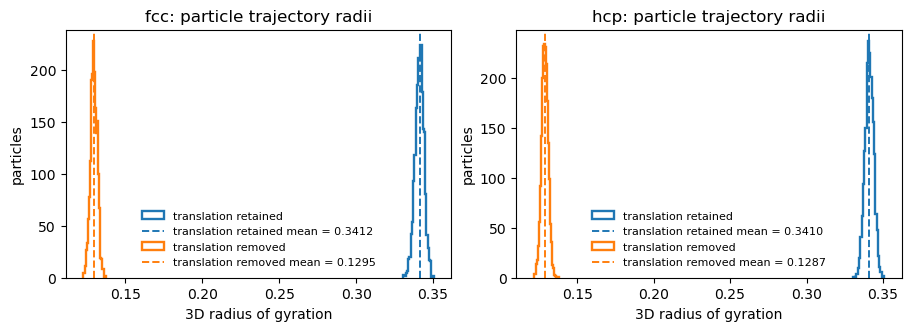

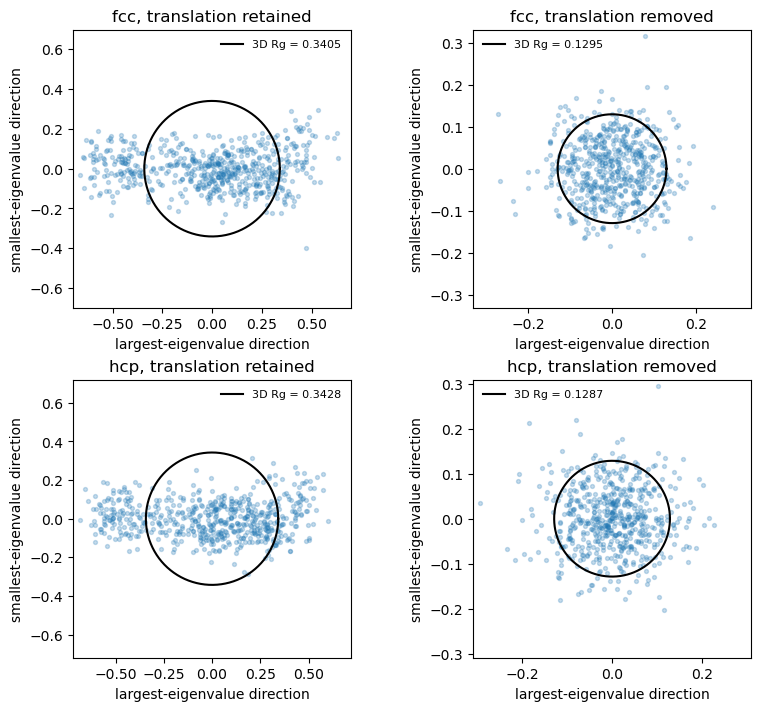

In [69]:
# Experiment 2: How large is each particle's position cloud?



def calculate_radius_of_gyration(centered_positions):
    """Return one three-dimensional radius of gyration per particle."""
    squared_distance = np.sum(centered_positions**2, axis=2)
    return np.sqrt(squared_distance.mean(axis=0))


def radius_of_gyration(positions, boxes, remove_global_translation=True):
    """Calculate trajectory radii from wrapped particle positions."""
    unwrapped = unwrap_positions(positions, boxes)
    if remove_global_translation:
        unwrapped = remove_shared_translation(unwrapped)
    _, centered, _ = calculate_gaussian_distribution(unwrapped)
    return calculate_radius_of_gyration(centered)


def trajectory_radius_of_gyration_reports(
    label,
    path,
    n_particles=RG_N_PARTICLES,
    n_frames=RG_N_FRAMES,
    seed=SEED,
):
    """Read fixed particle IDs once, then calculate both translation modes."""
    positions, boxes, timesteps, atom_ids = read_sampled_lammpstrj(
        path,
        n_particles=n_particles,
        max_frames=n_frames,
        frame_stride=1,
        seed=seed,
    )
    if len(positions) != n_frames:
        raise ValueError(f"Requested {n_frames} frames, but {path} contains only {len(positions)}.")

    original_unwrapped = unwrap_positions(positions, boxes)
    reports = {}
    for remove_translation in (False, True):
        name = "translation removed" if remove_translation else "translation retained"
        unwrapped = original_unwrapped
        if remove_translation:
            unwrapped = remove_shared_translation(unwrapped)

        centers, centered, covariances = calculate_gaussian_distribution(unwrapped)
        eigenvalues, eigenvectors = np.linalg.eigh(covariances)
        eigenvalues = eigenvalues[:, ::-1]
        eigenvectors = eigenvectors[:, :, ::-1]

        reports[name] = {
            "label": label,
            "atom_ids": atom_ids,
            "timesteps": timesteps,
            "centers": centers,
            "centered_positions": centered,
            "radii": calculate_radius_of_gyration(centered),
            "covariance_eigenvalues": eigenvalues,
            "covariance_eigenvectors": eigenvectors,
        }
    return reports


# FCC and HCP contain 601 frames; the liquid trajectory contains only 301.
rg_reports = {
    label: trajectory_radius_of_gyration_reports(label, TRAJECTORIES[label])
    for label in ("fcc", "hcp")
}

rg_summary = []
for label, translation_reports in rg_reports.items():
    for translation_name, report in translation_reports.items():
        radii = report["radii"]
        rg_summary.append({
            "label": label,
            "translation": translation_name,
            "n_particles": len(radii),
            "n_frames": len(report["timesteps"]),
            "mean_radius": np.mean(radii),
            "median_radius": np.median(radii),
            "std_radius": np.std(radii, ddof=1),
            "min_radius": np.min(radii),
            "max_radius": np.max(radii),
        })

rg_summary = pd.DataFrame(rg_summary).set_index(["label", "translation"])
display(rg_summary)

# Select one median-radius atom after translation removal and reuse it in both modes.
rg_representative_particles = {}
for label, translation_reports in rg_reports.items():
    radii = translation_reports["translation removed"]["radii"]
    rg_representative_particles[label] = int(np.argsort(radii)[len(radii) // 2])

for label, translation_reports in rg_reports.items():
    particle = rg_representative_particles[label]
    atom_id = int(translation_reports["translation removed"]["atom_ids"][particle])
    print()
    print(f"{label.upper()} representative atom id {atom_id}")
    for translation_name, report in translation_reports.items():
        print(f"  {translation_name}: 3D Rg = {report['radii'][particle]:.6f}")

# Population view: radius distributions and their means in one plot per structure.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
colors = {
    "translation retained": "tab:blue",
    "translation removed": "tab:orange",
}
for ax, label in zip(axes, ("fcc", "hcp")):
    for translation_name, report in rg_reports[label].items():
        radii = report["radii"]
        color = colors[translation_name]
        ax.hist(
            radii, bins=25, histtype="step", lw=1.7,
            color=color, label=translation_name,
        )
        ax.axvline(
            radii.mean(), color=color, linestyle="--", lw=1.4,
            label=f"{translation_name} mean = {radii.mean():.4f}",
        )
    ax.set_title(f"{label}: particle trajectory radii")
    ax.set_xlabel("3D radius of gyration")
    ax.set_ylabel("particles")
    ax.legend(frameon=False, fontsize=8)
plt.show()

# Local view: show the calculated 3D radius on the principal point-cloud plane.
fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
angle = np.linspace(0, 2 * np.pi, 300)

for row, label in enumerate(("fcc", "hcp")):
    particle = rg_representative_particles[label]
    for column, translation_name in enumerate(
        ("translation retained", "translation removed")
    ):
        report = rg_reports[label][translation_name]
        centered = report["centered_positions"][:, particle, :]
        eigenvectors = report["covariance_eigenvectors"][particle]

        largest = centered @ eigenvectors[:, 0]
        smallest = centered @ eigenvectors[:, -1]
        radius_3d = report["radii"][particle]

        ax = axes[row, column]
        ax.scatter(largest, smallest, s=8, alpha=0.25)
        ax.plot(
            radius_3d * np.cos(angle), radius_3d * np.sin(angle),
            color="black", lw=1.5, label=f"3D Rg = {radius_3d:.4f}",
        )

        limit = 1.05 * max(
            np.max(np.abs(largest)), np.max(np.abs(smallest)), radius_3d
        )
        ax.set_xlim(-limit, limit)
        ax.set_ylim(-limit, limit)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"{label}, {translation_name}")
        ax.set_xlabel("largest-eigenvalue direction")
        ax.set_ylabel("smallest-eigenvalue direction")
        ax.legend(frameon=False, fontsize=8)

plt.show()


## Experiment 3: Global displacement cloud

Pools consecutive minimum-image displacement vectors over particles and intervals.


n_frames  n_particles  n_vectors  \
label  translation                                              
fcc    translation retained       601         2000    1200000   
       translation removed        601         2000    1200000   
hcp    translation retained       601         2000    1200000   
       translation removed        601         2000    1200000   
liquid translation retained       301         2000     600000   
       translation removed        301         2000     600000   

                             mean_displacement_norm  anisotropy_ratio  \
label  translation                                                      
fcc    translation retained            1.442938e-03          1.004983   
       translation removed             4.483000e-18          1.002318   
hcp    translation retained            1.445235e-03          1.052465   
       translation removed             7.525442e-18          1.052835   
liquid translation retained            1.072946e-02          1.006489   
       translation removed             6.444065e-17          1.006514   

                             mahalanobis_ks_p  max_abs_skew  \
label  translation                                            
fcc    translation retained      4.651560e-09      0.003388   
       translation removed       1.270995e-10      0.003033   
hcp    translation retained      2.327934e-12      0.002105   
       translation removed       1.566951e-12      0.001769   
liquid translation retained      8.025410e-02      0.003889   
       translation removed       7.208608e-02      0.004200   

                             max_abs_excess_kurtosis  
label  translation                                    
fcc    translation retained                 0.044526  
       translation removed                  0.046405  
hcp    translation retained                 0.030874  
       translation removed                  0.031012  
liquid translation retained                 0.014749  
       translation removed                  0.014866


FCC, translation retained
mean displacement: [0.001266 0.000671 0.000169]
Mahalanobis KS p-value: 4.652e-09
anisotropy ratio: 1.005


,x,y,z
x,0.011405,0.000022,-0.000008
y,0.000022,0.011391,-0.000006
z,-0.000008,-0.000006,0.011421



FCC, translation removed
mean displacement: [ 4.136090e-18 -1.015819e-18  1.399344e-18]
Mahalanobis KS p-value: 1.271e-10
anisotropy ratio: 1.002


,x,y,z
x,0.011215,0.000006,0.000003
y,0.000006,0.011206,-0.000002
z,0.000003,-0.000002,0.011228


...

,x,y,z
x,0.011297,0.000008,0.000007
y,0.000008,0.011183,-0.000013
z,0.000007,-0.000013,0.010731



LIQUID, translation retained
mean displacement: [0.007158 0.007798 0.001752]
Mahalanobis KS p-value: 0.08025
anisotropy ratio: 1.006


,x,y,z
x,7.105997,-0.010949,-0.000200
y,-0.010949,7.069316,-0.008874
z,-0.000200,-0.008874,7.089524



LIQUID, translation removed
mean displacement: [-2.699174e-17 -2.823815e-17 -5.125086e-17]
Mahalanobis KS p-value: 0.07209
anisotropy ratio: 1.007


,x,y,z
x,7.102490,-0.010789,-0.000455
y,-0.010789,7.065508,-0.008970
z,-0.000455,-0.008970,7.085655


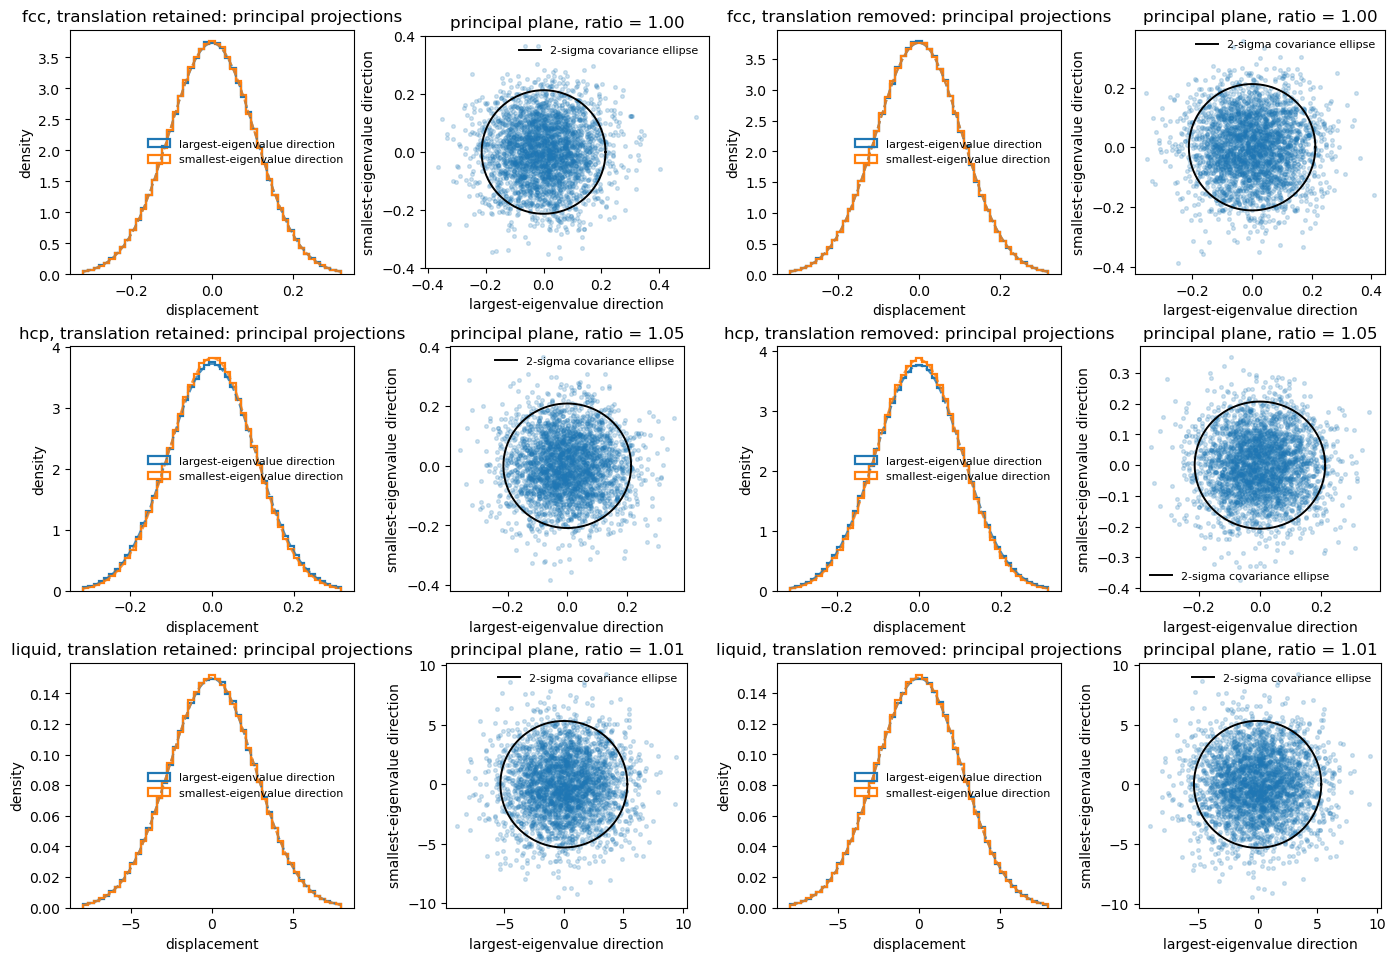

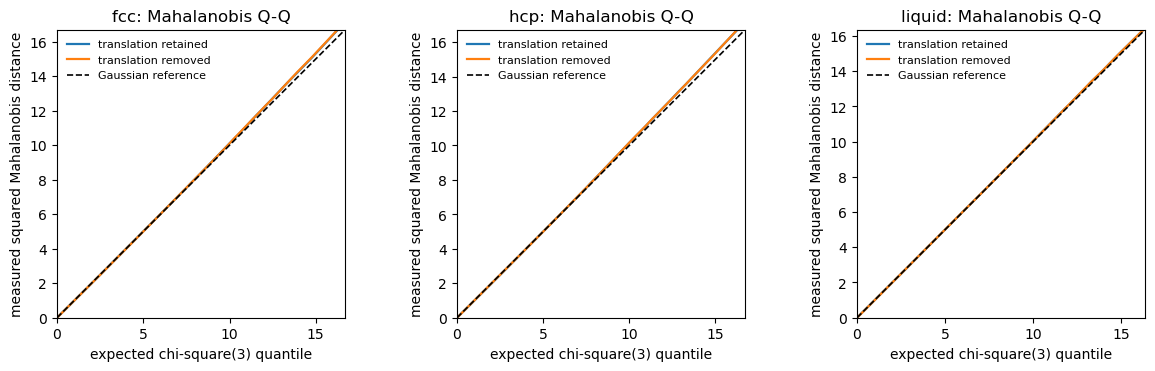

In [70]:
# Experiment 3: Is the global displacement-vector cloud approximately Gaussian?



def calculate_displacements(positions, boxes=None):
    """Calculate consecutive displacement vectors, with PBC when boxes are given."""
    displacements = np.diff(positions, axis=0)
    if boxes is None:
        return displacements

    boxes = np.asarray(boxes, dtype=np.float64)
    step_boxes = boxes if boxes.ndim == 1 else boxes[1:]
    return minimum_image(displacements, step_boxes)


def remove_shared_displacement(displacements):
    """Remove the mean particle displacement separately for every frame interval."""
    return displacements - displacements.mean(axis=1, keepdims=True)


def calculate_global_gaussian_distribution(vectors):
    """Calculate one mean and covariance after pooling all displacement vectors."""
    flat_vectors = vectors.reshape(-1, 3)
    center = flat_vectors.mean(axis=0)
    centered = flat_vectors - center
    covariance = np.cov(centered.T, bias=False)
    return center, centered, covariance


def calculate_global_gaussianity_metrics(centered, covariance):
    """Reuse the Experiment 1 diagnostic for one pooled three-dimensional cloud."""
    metrics = calculate_gaussianity_metrics(
        centered[:, None, :], covariance[None, :, :]
    )
    return {
        "mahalanobis_d2": metrics["mahalanobis_d2"][:, 0],
        "mahalanobis_ks_p": metrics["mahalanobis_ks_p"][0],
        "marginal_skew_xyz": metrics["marginal_skew_xyz"][0],
        "marginal_excess_kurtosis_xyz": metrics[
            "marginal_excess_kurtosis_xyz"
        ][0],
    }


def global_displacement_cloud_report(
    label,
    positions,
    boxes,
    remove_global_translation=True,
):
    """Analyze all sampled displacement vectors as one global point cloud."""
    displacements = calculate_displacements(positions, boxes)
    if remove_global_translation:
        displacements = remove_shared_displacement(displacements)

    center, centered, covariance = calculate_global_gaussian_distribution(
        displacements
    )
    metrics = calculate_global_gaussianity_metrics(centered, covariance)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    return {
        "label": label,
        "remove_global_translation": remove_global_translation,
        "n_frames": len(positions),
        "n_particles": positions.shape[1],
        "n_vectors": len(centered),
        "displacements": displacements,
        "mean_displacement": center,
        "centered_displacements": centered,
        "covariance": covariance,
        "covariance_eigenvalues": eigenvalues,
        "covariance_eigenvectors": eigenvectors,
        "anisotropy_ratio": eigenvalues[0] / eigenvalues[-1],
        **metrics,
    }


def trajectory_global_displacement_reports(
    label,
    path,
    n_particles=DISPLACEMENT_N_PARTICLES,
    n_frames=None,
    seed=SEED,
):
    """Read fixed particle IDs once, then analyze both translation modes."""
    if n_frames is None:
        n_frames = DISPLACEMENT_FRAMES[label]

    positions, boxes, timesteps, atom_ids = read_sampled_lammpstrj(
        path,
        n_particles=n_particles,
        max_frames=n_frames,
        frame_stride=1,
        seed=seed,
    )
    if len(positions) != n_frames:
        raise ValueError(f"Requested {n_frames} frames, but {path} contains only {len(positions)}.")

    reports = {}
    for remove_translation in (False, True):
        name = "translation removed" if remove_translation else "translation retained"
        report = global_displacement_cloud_report(
            label, positions, boxes, remove_translation
        )
        report["atom_ids"] = atom_ids
        report["timesteps"] = timesteps
        reports[name] = report
    return reports


global_displacement_reports = {
    label: trajectory_global_displacement_reports(label, TRAJECTORIES[label])
    for label in ("fcc", "hcp", "liquid")
}

global_displacement_summary = []
for label, translation_reports in global_displacement_reports.items():
    for translation_name, report in translation_reports.items():
        global_displacement_summary.append({
            "label": label,
            "translation": translation_name,
            "n_frames": report["n_frames"],
            "n_particles": report["n_particles"],
            "n_vectors": report["n_vectors"],
            "mean_displacement_norm": np.linalg.norm(report["mean_displacement"]),
            "anisotropy_ratio": report["anisotropy_ratio"],
            "mahalanobis_ks_p": report["mahalanobis_ks_p"],
            "max_abs_skew": np.max(np.abs(report["marginal_skew_xyz"])),
            "max_abs_excess_kurtosis": np.max(
                np.abs(report["marginal_excess_kurtosis_xyz"])
            ),
        })

global_displacement_summary = pd.DataFrame(global_displacement_summary).set_index(
    ["label", "translation"]
)
display(global_displacement_summary)

for label, translation_reports in global_displacement_reports.items():
    for translation_name, report in translation_reports.items():
        print()
        print(f"{label.upper()}, {translation_name}")
        print(
            "mean displacement:",
            np.array2string(report["mean_displacement"], precision=6),
        )
        print("Mahalanobis KS p-value:", f"{report['mahalanobis_ks_p']:.4g}")
        print("anisotropy ratio:", f"{report['anisotropy_ratio']:.3f}")
        display(pd.DataFrame(
            report["covariance"], index=list("xyz"), columns=list("xyz")
        ))

# Principal-axis distributions and point clouds for both translation modes.
translation_order = ("translation retained", "translation removed")
fig, axes = plt.subplots(3, 4, figsize=(14, 9.5), constrained_layout=True)

for row, label in enumerate(("fcc", "hcp", "liquid")):
    for mode, translation_name in enumerate(translation_order):
        report = global_displacement_reports[label][translation_name]
        centered = report["centered_displacements"]
        eigenvalues = report["covariance_eigenvalues"]
        eigenvectors = report["covariance_eigenvectors"]

        largest = centered @ eigenvectors[:, 0]
        smallest = centered @ eigenvectors[:, -1]
        histogram_axis = axes[row, 2 * mode]
        scatter_axis = axes[row, 2 * mode + 1]

        projection_limit = np.quantile(
            np.abs(np.concatenate([largest, smallest])), 0.997
        )
        bins = np.linspace(-projection_limit, projection_limit, 50)
        x = np.linspace(-projection_limit, projection_limit, 400)

        histogram_axis.hist(
            largest, bins=bins, density=True, histtype="step", lw=1.6,
            label="largest-eigenvalue direction",
        )
        histogram_axis.hist(
            smallest, bins=bins, density=True, histtype="step", lw=1.6,
            label="smallest-eigenvalue direction",
        )
        histogram_axis.plot(
            x, norm.pdf(x, scale=np.sqrt(eigenvalues[0])),
            color="tab:blue", linestyle="--", alpha=0.8,
        )
        histogram_axis.plot(
            x, norm.pdf(x, scale=np.sqrt(eigenvalues[-1])),
            color="tab:orange", linestyle="--", alpha=0.8,
        )
        histogram_axis.set_title(
            f"{label}, {translation_name}: principal projections"
        )
        histogram_axis.set_xlabel("displacement")
        histogram_axis.set_ylabel("density")
        histogram_axis.legend(frameon=False, fontsize=8)

        plot_indices = np.linspace(
            0, len(largest) - 1, min(3000, len(largest)), dtype=int
        )
        scatter_axis.scatter(
            largest[plot_indices], smallest[plot_indices], s=7, alpha=0.2
        )
        angle = np.linspace(0, 2 * np.pi, 300)
        scatter_axis.plot(
            2 * np.sqrt(eigenvalues[0]) * np.cos(angle),
            2 * np.sqrt(eigenvalues[-1]) * np.sin(angle),
            color="black", lw=1.4, label="2-sigma covariance ellipse",
        )
        scatter_axis.set_aspect("equal", adjustable="box")
        scatter_axis.set_title(
            f"principal plane, ratio = {report['anisotropy_ratio']:.2f}"
        )
        scatter_axis.set_xlabel("largest-eigenvalue direction")
        scatter_axis.set_ylabel("smallest-eigenvalue direction")
        scatter_axis.legend(frameon=False, fontsize=8)

plt.show()

# Global Gaussian diagnostic: Mahalanobis distances should follow chi-square(3).
qq_probabilities = np.linspace(0.001, 0.999, 1000)
expected_chi_square = chi2(df=3).ppf(qq_probabilities)
qq_colors = {
    "translation retained": "tab:blue",
    "translation removed": "tab:orange",
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

for ax, label in zip(axes, ("fcc", "hcp", "liquid")):
    largest_value = expected_chi_square[-1]
    for translation_name, report in global_displacement_reports[label].items():
        measured = np.quantile(report["mahalanobis_d2"], qq_probabilities)
        largest_value = max(largest_value, measured[-1])
        ax.plot(
            expected_chi_square, measured, lw=1.6,
            color=qq_colors[translation_name], label=translation_name,
        )

    ax.plot(
        [0, largest_value], [0, largest_value],
        color="black", linestyle="--", lw=1.2, label="Gaussian reference",
    )
    ax.set_xlim(0, largest_value)
    ax.set_ylim(0, largest_value)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{label}: Mahalanobis Q-Q")
    ax.set_xlabel("expected chi-square(3) quantile")
    ax.set_ylabel("measured squared Mahalanobis distance")
    ax.legend(frameon=False, fontsize=8)

plt.show()


## Experiment 4: Local displacement clouds

Preserves particle identity and computes displacement statistics per particle.


n_intervals  n_particles  median_anisotropy  \
label  translation                                                         
fcc    translation retained          600         2000           1.218726   
       translation removed           600         2000           1.219742   
hcp    translation retained          600         2000           1.234005   
       translation removed           600         2000           1.233541   
liquid translation retained          300         2000           1.264041   
       translation removed           300         2000           1.264585   

                             p90_anisotropy  p99_anisotropy  median_ks_p  \
label  translation                                                         
fcc    translation retained        1.344366        1.469643     0.689563   
       translation removed         1.345157        1.476101     0.703612   
hcp    translation retained        1.352345        1.471651     0.697449   
       translation removed         1.355698        1.475904     0.697210   
liquid translation retained        1.412732        1.579927     0.706038   
       translation removed         1.410566        1.575599     0.700616   

                             fraction_ks_p_below_0.05  median_max_abs_skew  \
label  translation                                                           
fcc    translation retained                    0.0065             0.111644   
       translation removed                     0.0040             0.108867   
hcp    translation retained                    0.0060             0.111887   
       translation removed                     0.0065             0.111694   
liquid translation retained                    0.0030             0.175527   
       translation removed                     0.0040             0.175480   

                             median_max_abs_excess_kurtosis  
label  translation                                           
fcc    translation retained                        0.261287  
       translation removed                         0.266631  
hcp    translation retained                        0.258154  
       translation removed                         0.260148  
liquid translation retained                        0.336063  
       translation removed                         0.334571


FCC, translation retained: representative atom id 75640
mean displacement: [1.037819e-03 5.353411e-04 1.994225e-05]
Mahalanobis KS p-value: 0.8687
anisotropy ratio: 1.331


,x,y,z
x,0.011349,-0.000398,-0.000482
y,-0.000398,0.012021,-0.001383
z,-0.000482,-0.001383,0.010909



FCC, translation removed: representative atom id 75640
mean displacement: [-0.000228 -0.000136 -0.00015 ]
Mahalanobis KS p-value: 0.7038
anisotropy ratio: 1.342


,x,y,z
x,0.011162,-0.000580,-0.000467
y,-0.000580,0.011658,-0.001406
z,-0.000467,-0.001406,0.010896


...

,x,y,z
x,0.012497,0.001499,0.000506
y,0.001499,0.010751,-0.000030
z,0.000506,-0.000030,0.012843



LIQUID, translation retained: representative atom id 78166
mean displacement: [0.177448 0.020735 0.156197]
Mahalanobis KS p-value: 0.7283
anisotropy ratio: 1.343


,x,y,z
x,7.036430,-0.818314,-0.059828
y,-0.818314,7.215989,0.652450
z,-0.059828,0.652450,7.182751



LIQUID, translation removed: representative atom id 78166
mean displacement: [0.170289 0.012937 0.154445]
Mahalanobis KS p-value: 0.7006
anisotropy ratio: 1.351


,x,y,z
x,7.043962,-0.854628,-0.058108
y,-0.854628,7.187711,0.636308
z,-0.058108,0.636308,7.211192


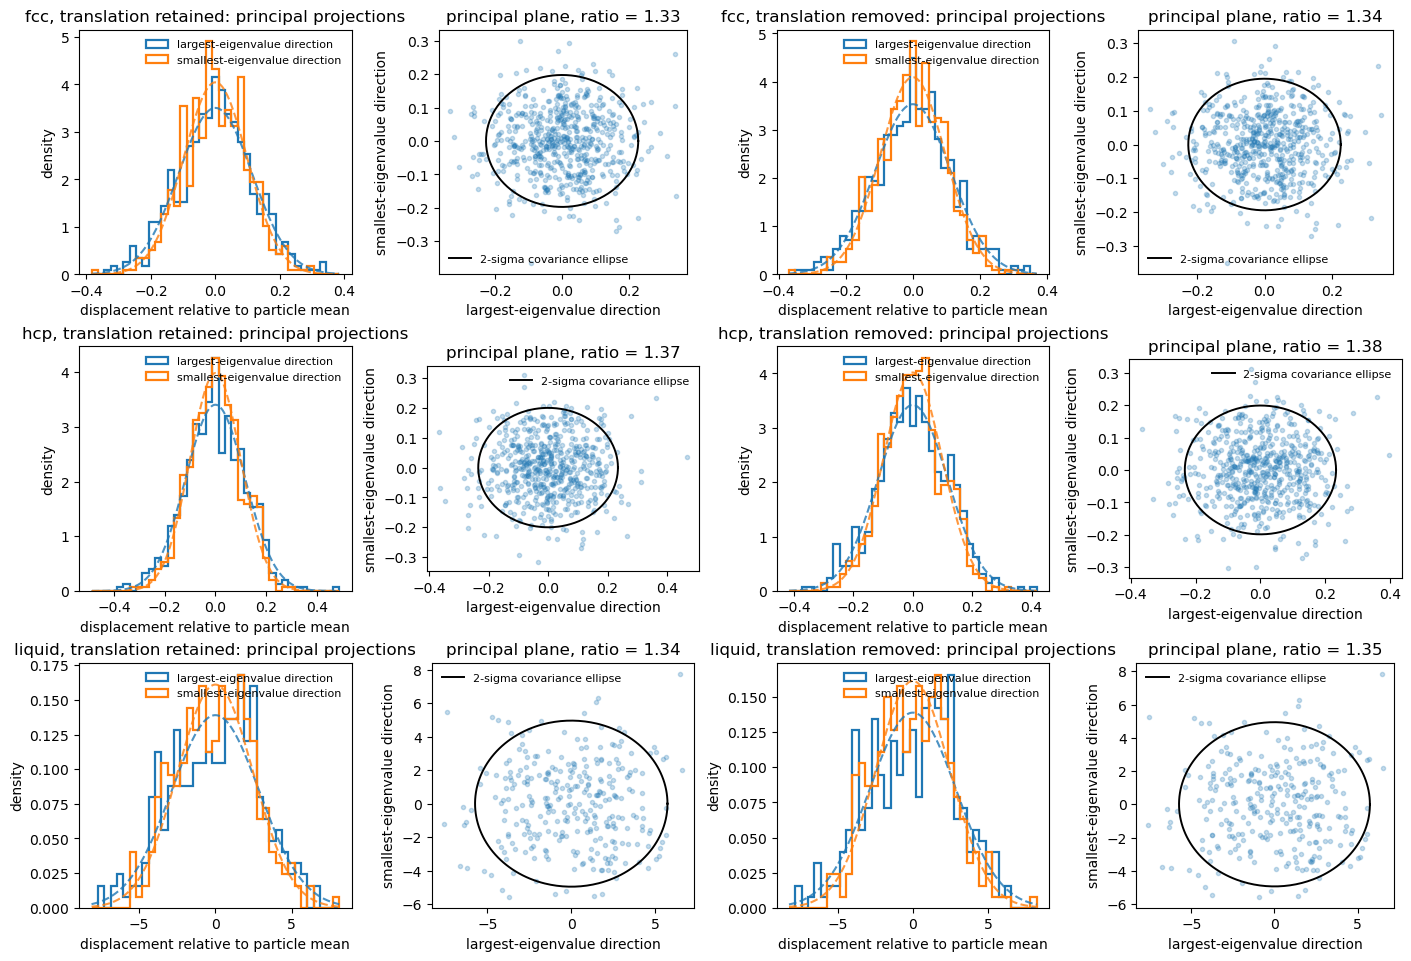

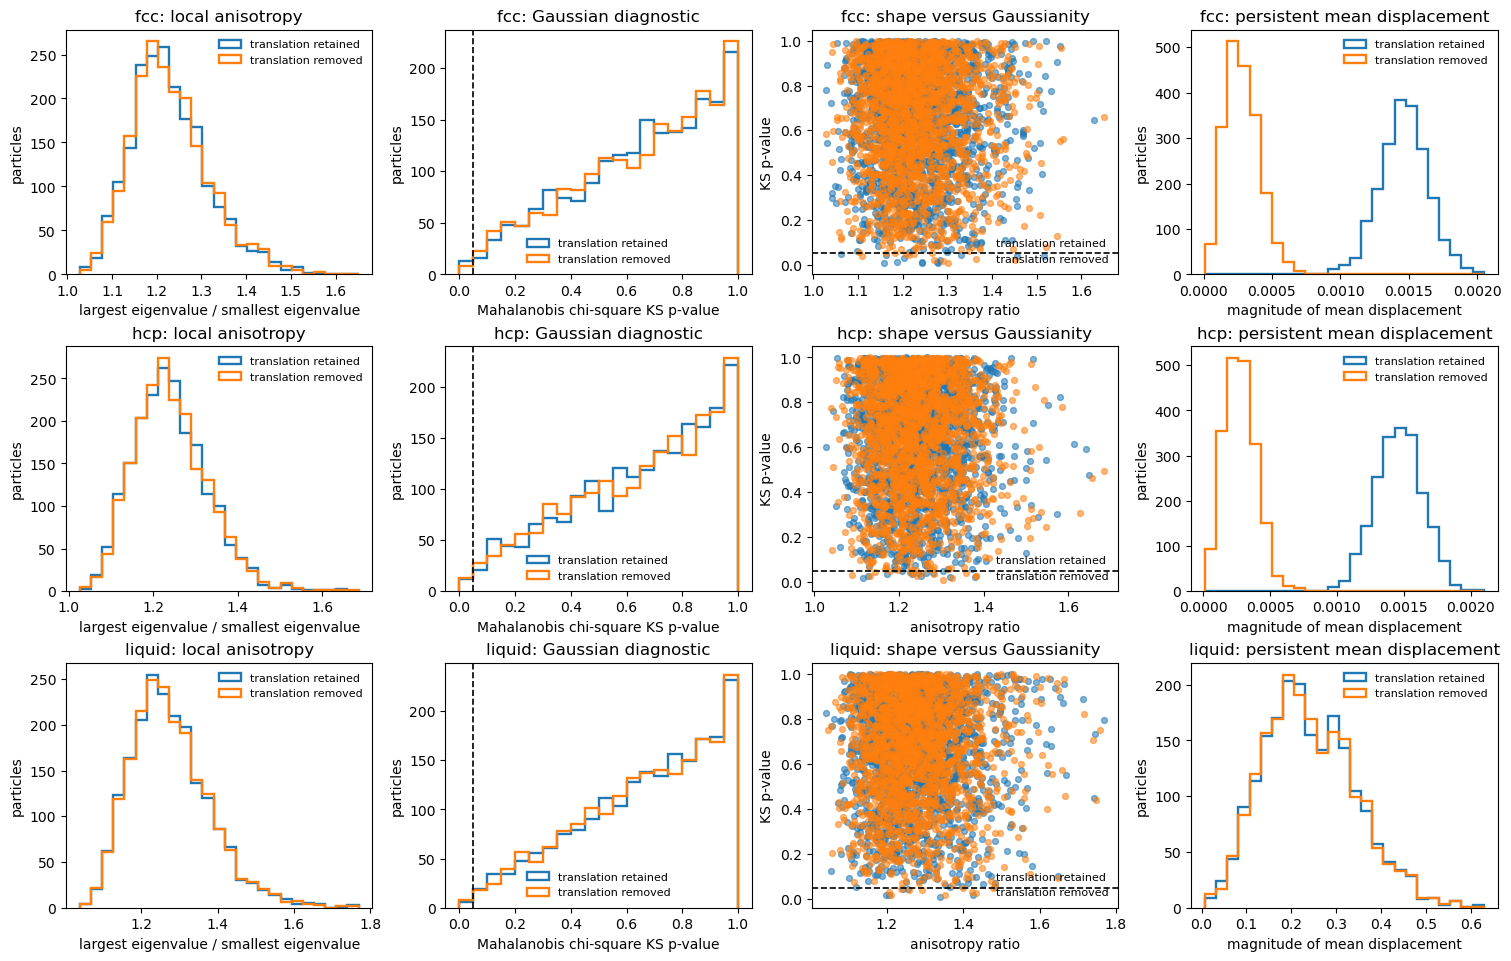

In [71]:
# Experiment 4: Is each particle's displacement-vector cloud approximately Gaussian?


def local_displacement_cloud_report(
    label,
    displacements,
    atom_ids,
    timesteps,
    remove_global_translation,
):
    """Calculate one displacement mean, covariance, and diagnostic per particle."""
    # No reshape here: the particle axis stays intact.
    centers, centered, covariances = calculate_gaussian_distribution(displacements)
    metrics = calculate_gaussianity_metrics(centered, covariances)

    eigenvalues, eigenvectors = np.linalg.eigh(covariances)
    eigenvalues = eigenvalues[:, ::-1]
    eigenvectors = eigenvectors[:, :, ::-1]
    anisotropy = eigenvalues[:, 0] / np.maximum(
        eigenvalues[:, -1], np.finfo(float).eps
    )

    return {
        "label": label,
        "remove_global_translation": remove_global_translation,
        "n_frames": len(timesteps),
        "n_intervals": len(displacements),
        "n_particles": displacements.shape[1],
        "atom_ids": atom_ids,
        "timesteps": timesteps,
        "mean_displacements": centers,
        "centered_displacements": centered,
        "covariances": covariances,
        "covariance_eigenvalues": eigenvalues,
        "covariance_eigenvectors": eigenvectors,
        "anisotropy_ratio": anisotropy,
        **metrics,
    }


# Reuse the retained/removed displacement tensors calculated in Experiment 3.
local_displacement_reports = {}
for label, global_reports in global_displacement_reports.items():
    local_displacement_reports[label] = {}
    for translation_name, global_report in global_reports.items():
        local_displacement_reports[label][translation_name] = (
            local_displacement_cloud_report(
                label=label,
                displacements=global_report["displacements"],
                atom_ids=global_report["atom_ids"],
                timesteps=global_report["timesteps"],
                remove_global_translation=global_report[
                    "remove_global_translation"
                ],
            )
        )


local_displacement_summary = []
for label, translation_reports in local_displacement_reports.items():
    for translation_name, report in translation_reports.items():
        p_values = report["mahalanobis_ks_p"]
        anisotropy = report["anisotropy_ratio"]
        skew = report["marginal_skew_xyz"]
        kurtosis = report["marginal_excess_kurtosis_xyz"]

        local_displacement_summary.append({
            "label": label,
            "translation": translation_name,
            "n_intervals": report["n_intervals"],
            "n_particles": report["n_particles"],
            "median_anisotropy": np.median(anisotropy),
            "p90_anisotropy": np.quantile(anisotropy, 0.90),
            "p99_anisotropy": np.quantile(anisotropy, 0.99),
            "median_ks_p": np.median(p_values),
            "fraction_ks_p_below_0.05": np.mean(p_values < 0.05),
            "median_max_abs_skew": np.median(np.max(np.abs(skew), axis=1)),
            "median_max_abs_excess_kurtosis": np.median(
                np.max(np.abs(kurtosis), axis=1)
            ),
        })

local_displacement_summary = pd.DataFrame(local_displacement_summary).set_index(
    ["label", "translation"]
)
display(local_displacement_summary)


# Select one median-p-value particle after translation removal and reuse it in both modes.
local_displacement_representatives = {}
for label, translation_reports in local_displacement_reports.items():
    p_values = translation_reports["translation removed"]["mahalanobis_ks_p"]
    local_displacement_representatives[label] = int(
        np.argsort(p_values)[len(p_values) // 2]
    )

for label, translation_reports in local_displacement_reports.items():
    particle = local_displacement_representatives[label]
    atom_id = int(translation_reports["translation removed"]["atom_ids"][particle])
    for translation_name, report in translation_reports.items():
        print()
        print(f"{label.upper()}, {translation_name}: representative atom id {atom_id}")
        print(
            "mean displacement:",
            np.array2string(report["mean_displacements"][particle], precision=6),
        )
        print("Mahalanobis KS p-value:", f"{report['mahalanobis_ks_p'][particle]:.4f}")
        print("anisotropy ratio:", f"{report['anisotropy_ratio'][particle]:.3f}")
        display(pd.DataFrame(
            report["covariances"][particle], index=list("xyz"), columns=list("xyz")
        ))


# Show representative local displacement clouds for both translation modes.
translation_order = ("translation retained", "translation removed")
fig, axes = plt.subplots(3, 4, figsize=(14, 9.5), constrained_layout=True)

for row, label in enumerate(("fcc", "hcp", "liquid")):
    particle = local_displacement_representatives[label]
    for mode, translation_name in enumerate(translation_order):
        report = local_displacement_reports[label][translation_name]
        centered = report["centered_displacements"][:, particle, :]
        eigenvalues = report["covariance_eigenvalues"][particle]
        eigenvectors = report["covariance_eigenvectors"][particle]

        largest = centered @ eigenvectors[:, 0]
        smallest = centered @ eigenvectors[:, -1]
        anisotropy = report["anisotropy_ratio"][particle]
        histogram_axis = axes[row, 2 * mode]
        scatter_axis = axes[row, 2 * mode + 1]

        projection_limit = 1.05 * np.max(
            np.abs(np.concatenate([largest, smallest]))
        )
        bins = np.linspace(-projection_limit, projection_limit, 40)
        x = np.linspace(-projection_limit, projection_limit, 400)

        histogram_axis.hist(
            largest, bins=bins, density=True, histtype="step", lw=1.6,
            label="largest-eigenvalue direction",
        )
        histogram_axis.hist(
            smallest, bins=bins, density=True, histtype="step", lw=1.6,
            label="smallest-eigenvalue direction",
        )
        histogram_axis.plot(
            x, norm.pdf(x, scale=np.sqrt(eigenvalues[0])),
            color="tab:blue", linestyle="--", alpha=0.8,
        )
        histogram_axis.plot(
            x, norm.pdf(x, scale=np.sqrt(eigenvalues[-1])),
            color="tab:orange", linestyle="--", alpha=0.8,
        )
        histogram_axis.set_title(
            f"{label}, {translation_name}: principal projections"
        )
        histogram_axis.set_xlabel("displacement relative to particle mean")
        histogram_axis.set_ylabel("density")
        histogram_axis.legend(frameon=False, fontsize=8)

        scatter_axis.scatter(largest, smallest, s=9, alpha=0.25)
        angle = np.linspace(0, 2 * np.pi, 300)
        scatter_axis.plot(
            2 * np.sqrt(eigenvalues[0]) * np.cos(angle),
            2 * np.sqrt(eigenvalues[-1]) * np.sin(angle),
            color="black", lw=1.4, label="2-sigma covariance ellipse",
        )
        scatter_axis.set_aspect("equal", adjustable="box")
        scatter_axis.set_title(f"principal plane, ratio = {anisotropy:.2f}")
        scatter_axis.set_xlabel("largest-eigenvalue direction")
        scatter_axis.set_ylabel("smallest-eigenvalue direction")
        scatter_axis.legend(frameon=False, fontsize=8)

plt.show()

# Population view: do local displacement statistics vary across particles?
local_colors = {
    "translation retained": "tab:blue",
    "translation removed": "tab:orange",
}
fig, axes = plt.subplots(3, 4, figsize=(15, 9.5), constrained_layout=True)

for row, label in enumerate(("fcc", "hcp", "liquid")):
    translation_reports = local_displacement_reports[label]

    anisotropy_values = np.concatenate([
        report["anisotropy_ratio"] for report in translation_reports.values()
    ])
    anisotropy_bins = np.linspace(
        anisotropy_values.min(), anisotropy_values.max(), 26
    )

    mean_displacement_values = np.concatenate([
        np.linalg.norm(report["mean_displacements"], axis=1)
        for report in translation_reports.values()
    ])
    mean_displacement_bins = np.linspace(
        mean_displacement_values.min(), mean_displacement_values.max(), 26
    )

    for translation_name, report in translation_reports.items():
        color = local_colors[translation_name]
        anisotropy = report["anisotropy_ratio"]
        p_values = report["mahalanobis_ks_p"]
        mean_displacement = np.linalg.norm(
            report["mean_displacements"], axis=1
        )

        axes[row, 0].hist(
            anisotropy, bins=anisotropy_bins, histtype="step",
            lw=1.7, color=color, label=translation_name,
        )
        axes[row, 1].hist(
            p_values, bins=np.linspace(0, 1, 21), histtype="step",
            lw=1.7, color=color, label=translation_name,
        )
        axes[row, 2].scatter(
            anisotropy, p_values, s=18, alpha=0.55,
            color=color, label=translation_name,
        )
        axes[row, 3].hist(
            mean_displacement, bins=mean_displacement_bins,
            histtype="step", lw=1.7, color=color, label=translation_name,
        )

    axes[row, 0].set_title(f"{label}: local anisotropy")
    axes[row, 0].set_xlabel("largest eigenvalue / smallest eigenvalue")
    axes[row, 0].set_ylabel("particles")

    axes[row, 1].axvline(0.05, color="black", linestyle="--", lw=1.2)
    axes[row, 1].set_title(f"{label}: Gaussian diagnostic")
    axes[row, 1].set_xlabel("Mahalanobis chi-square KS p-value")
    axes[row, 1].set_ylabel("particles")

    axes[row, 2].axhline(0.05, color="black", linestyle="--", lw=1.2)
    axes[row, 2].set_title(f"{label}: shape versus Gaussianity")
    axes[row, 2].set_xlabel("anisotropy ratio")
    axes[row, 2].set_ylabel("KS p-value")

    axes[row, 3].set_title(f"{label}: persistent mean displacement")
    axes[row, 3].set_xlabel("magnitude of mean displacement")
    axes[row, 3].set_ylabel("particles")

    for column in range(4):
        axes[row, column].legend(frameon=False, fontsize=8)

plt.show()


## Experiment 5: Synthetic controls

### 5a: Isotropic Gaussian baseline

Starts every particle at the origin and applies independent Gaussian displacement steps. The resulting trajectory has the same `(frames, particles, 3)` layout as the sampled simulation data. Only translation-removed displacement clouds are analyzed, matching the corrected results from Experiments 3 and 4.


trajectory shape: (601, 2000, 3)
all particles start at zero: True


,value
global anisotropy ratio,1.003386
global Mahalanobis KS p-value,0.896526
median local anisotropy ratio,1.180194
p90 local anisotropy ratio,1.272351
fraction local KS p-value below 0.05,0.001000



set step covariance


,x,y,z
x,0.005329,0.000000,0.000000
y,0.000000,0.005329,0.000000
z,0.000000,0.000000,0.005329


measured global covariance after translation removal


,x,y,z
x,0.005331,-0.000004,-0.000004
y,-0.000004,0.005334,-0.000002
z,-0.000004,-0.000002,0.005321


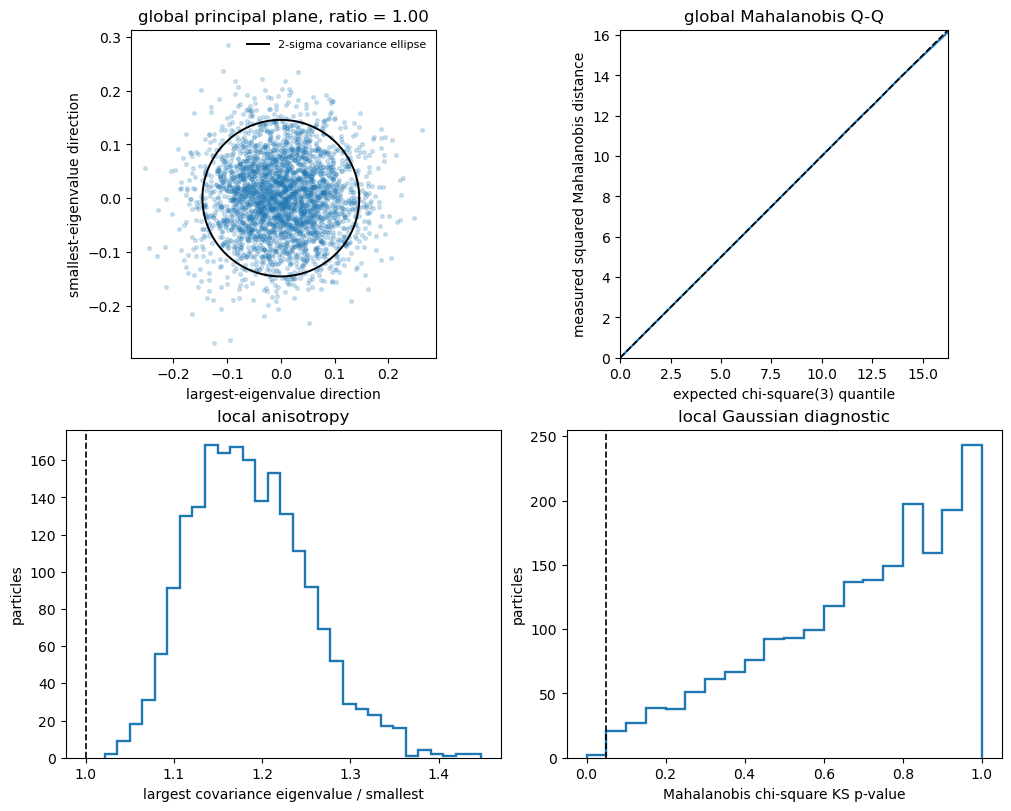

In [72]:
# Experiment 5a: isotropic Gaussian displacement baseline.


def generate_isotropic_gaussian_trajectory(
    n_frames,
    n_particles,
    covariance,
    seed=EXPERIMENT_5_SEED,
):
    """Start at zero and add one independent Gaussian displacement per step."""
    rng = np.random.default_rng(seed)
    positions = np.zeros((n_frames, n_particles, 3), dtype=float)
    positions[1:] = rng.multivariate_normal(
        mean=np.zeros(3),
        cov=covariance,
        size=(n_frames - 1, n_particles),
    )
    np.cumsum(positions[1:], axis=0, out=positions[1:])
    return positions


experiment_5a_covariance = EXPERIMENT_5A_STEP_STD**2 * np.eye(3)
experiment_5a_n_particles = PARTICLE_CLOUD_N_PARTICLES
if experiment_5a_n_particles is None:
    experiment_5a_n_particles = particle_cloud_reports["fcc"][
        "translation removed"
    ]["n_particles"]

experiment_5a_positions = generate_isotropic_gaussian_trajectory(
    n_frames=PARTICLE_CLOUD_N_FRAMES,
    n_particles=experiment_5a_n_particles,
    covariance=experiment_5a_covariance,
)

print("trajectory shape:", experiment_5a_positions.shape)
print("all particles start at zero:", np.all(experiment_5a_positions[0] == 0.0))


# Experiment 3 equivalent: pool all translation-removed displacement vectors.
experiment_5a_global = global_displacement_cloud_report(
    label="isotropic Gaussian baseline",
    positions=experiment_5a_positions,
    boxes=None,
    remove_global_translation=True,
)

# Experiment 4 equivalent: keep the particle axis and analyze every particle.
experiment_5a_local = local_displacement_cloud_report(
    label="isotropic Gaussian baseline",
    displacements=experiment_5a_global["displacements"],
    atom_ids=np.arange(experiment_5a_n_particles),
    timesteps=np.arange(PARTICLE_CLOUD_N_FRAMES),
    remove_global_translation=True,
)

experiment_5a_summary = pd.DataFrame({
    "value": {
        "global anisotropy ratio": experiment_5a_global["anisotropy_ratio"],
        "global Mahalanobis KS p-value": experiment_5a_global["mahalanobis_ks_p"],
        "median local anisotropy ratio": np.median(
            experiment_5a_local["anisotropy_ratio"]
        ),
        "p90 local anisotropy ratio": np.quantile(
            experiment_5a_local["anisotropy_ratio"], 0.90
        ),
        "fraction local KS p-value below 0.05": np.mean(
            experiment_5a_local["mahalanobis_ks_p"] < 0.05
        ),
    }
})
display(experiment_5a_summary)

print()
print("set step covariance")
display(pd.DataFrame(experiment_5a_covariance, index=list("xyz"), columns=list("xyz")))
print("measured global covariance after translation removal")
display(pd.DataFrame(
    experiment_5a_global["covariance"], index=list("xyz"), columns=list("xyz")
))


# Compact comparison with the corrected views from Experiments 3 and 4.
global_centered = experiment_5a_global["centered_displacements"]
global_eigenvalues = experiment_5a_global["covariance_eigenvalues"]
global_eigenvectors = experiment_5a_global["covariance_eigenvectors"]
largest = global_centered @ global_eigenvectors[:, 0]
smallest = global_centered @ global_eigenvectors[:, -1]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

plot_indices = np.linspace(
    0, len(largest) - 1, min(3000, len(largest)), dtype=int
)
axes[0, 0].scatter(
    largest[plot_indices], smallest[plot_indices], s=7, alpha=0.2
)
angle = np.linspace(0, 2 * np.pi, 300)
axes[0, 0].plot(
    2 * np.sqrt(global_eigenvalues[0]) * np.cos(angle),
    2 * np.sqrt(global_eigenvalues[-1]) * np.sin(angle),
    color="black", lw=1.4, label="2-sigma covariance ellipse",
)
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].set_title(
    f"global principal plane, ratio = {experiment_5a_global['anisotropy_ratio']:.2f}"
)
axes[0, 0].set_xlabel("largest-eigenvalue direction")
axes[0, 0].set_ylabel("smallest-eigenvalue direction")
axes[0, 0].legend(frameon=False, fontsize=8)

qq_probabilities = np.linspace(0.001, 0.999, 1000)
expected = chi2(df=3).ppf(qq_probabilities)
measured = np.quantile(
    experiment_5a_global["mahalanobis_d2"], qq_probabilities
)
qq_limit = max(expected[-1], measured[-1])
axes[0, 1].plot(expected, measured, lw=1.6)
axes[0, 1].plot(
    [0, qq_limit], [0, qq_limit], color="black", linestyle="--", lw=1.2
)
axes[0, 1].set_xlim(0, qq_limit)
axes[0, 1].set_ylim(0, qq_limit)
axes[0, 1].set_aspect("equal", adjustable="box")
axes[0, 1].set_title("global Mahalanobis Q-Q")
axes[0, 1].set_xlabel("expected chi-square(3) quantile")
axes[0, 1].set_ylabel("measured squared Mahalanobis distance")

axes[1, 0].hist(
    experiment_5a_local["anisotropy_ratio"], bins=30, histtype="step", lw=1.7
)
axes[1, 0].axvline(1.0, color="black", linestyle="--", lw=1.2)
axes[1, 0].set_title("local anisotropy")
axes[1, 0].set_xlabel("largest covariance eigenvalue / smallest")
axes[1, 0].set_ylabel("particles")

axes[1, 1].hist(
    experiment_5a_local["mahalanobis_ks_p"],
    bins=np.linspace(0, 1, 21),
    histtype="step",
    lw=1.7,
)
axes[1, 1].axvline(0.05, color="black", linestyle="--", lw=1.2)
axes[1, 1].set_title("local Gaussian diagnostic")
axes[1, 1].set_xlabel("Mahalanobis chi-square KS p-value")
axes[1, 1].set_ylabel("particles")

plt.show()
